## Configuración e Importación

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar el dataset YA PROCESADO
df = pd.read_csv("..\Data\marketing_simulated_niche.csv")

print(f"Dataset cargado con {df.shape[0]} registros.")
df.head()

Dataset cargado con 200000 registros.


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Conversions,Value_per_Conversion,Revenue,CPA
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.130274,16174.0,0.015572,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,65.918701,250,16425.861796,245.362843
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.064785,11566.0,-0.863015,New York,German,116,7523,7,Fashionistas,2021-01-02,7.515073,200,1584.365277,1539.040341
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.071822,10200.0,-0.187455,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,41.944299,180,8287.957132,243.179652
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.117923,12724.0,-0.452286,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,25.589206,250,6969.108908,497.240916
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.058745,16452.0,-0.671376,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,22.264398,250,5406.515451,738.937578


## Análisis Exploratorio

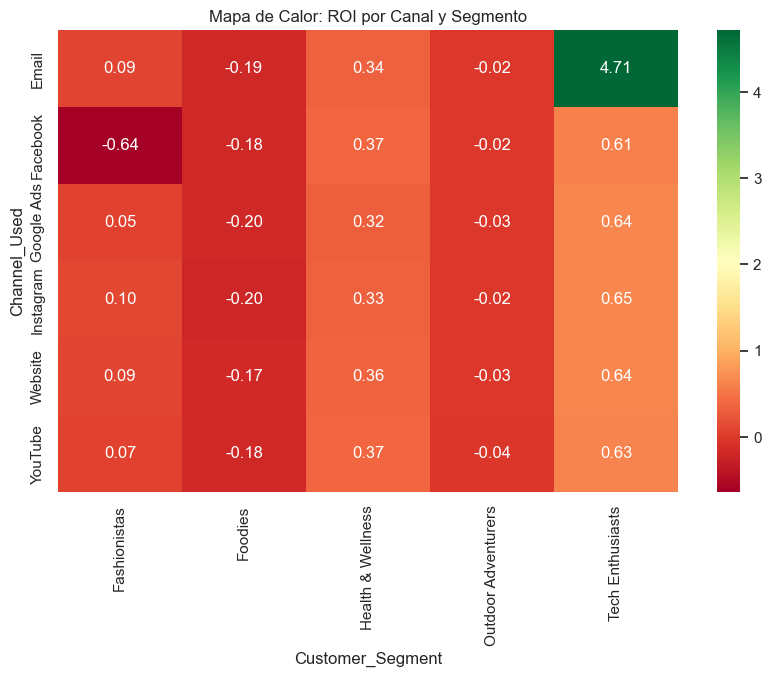

In [6]:
# ROI promedio por Canal y Segmento
pivot_roi = df.pivot_table(index='Channel_Used', columns='Customer_Segment', values='ROI', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_roi, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Mapa de Calor: ROI por Canal y Segmento")
plt.show()

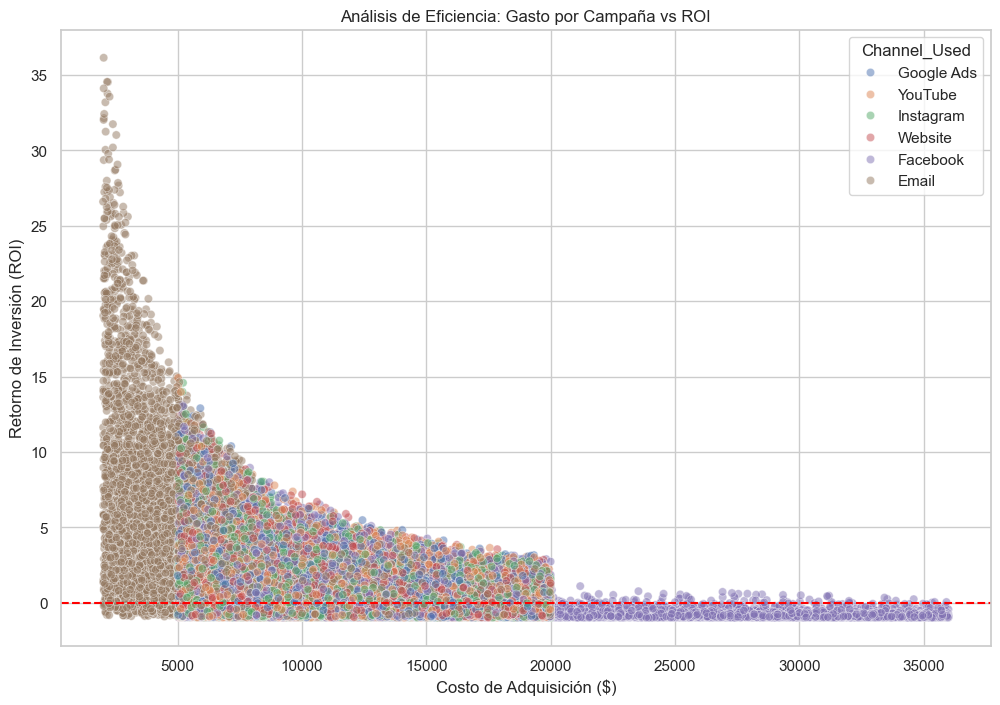

In [7]:
plt.figure(figsize=(12, 8))

# Graficamos todos los puntos
sns.scatterplot(data=df, x='Acquisition_Cost', y='ROI', hue='Channel_Used', alpha=0.5)

# Resaltamos el Agujero Negro y la Mina de Oro
plt.axhline(0, color='red', linestyle='--') # Línea de ROI cero
plt.title("Análisis de Eficiencia: Gasto por Campaña vs ROI")
plt.xlabel("Costo de Adquisición ($)")
plt.ylabel("Retorno de Inversión (ROI)")
plt.show()

In [9]:
# Filtrar campañas con ROI negativo
negative_roi = df[df['ROI'] < 0]
total_waste = negative_roi['Acquisition_Cost'].sum()
avg_cpa_waste = negative_roi['CPA'].mean()

print(f"Capital en Riesgo (ROI Negativo): ${total_waste:,.2f}")
print(f"CPA Promedio en campañas ineficientes: ${avg_cpa_waste:.2f}")

# El Nicho Ganador
niche = df[(df['Channel_Used'] == 'Email') & (df['Customer_Segment'] == 'Tech Enthusiasts')]
print(f"\nEficiencia del Nicho Encontrado (Email + Tech):")
print(f"ROI Promedio: {niche['ROI'].mean():.2f}")
print(f"CPA Promedio: ${niche['CPA'].mean():.2f}")

Capital en Riesgo (ROI Negativo): $1,663,484,491.60
CPA Promedio en campañas ineficientes: $921.65

Eficiencia del Nicho Encontrado (Email + Tech):
ROI Promedio: 4.71
CPA Promedio: $156.18


### Conclusiones
Tras modelar el comportamiento del presupuesto bajo reglas de mercado realistas, hemos detectado una asimetría masiva en la eficiencia del capital:

* El "Agujero Negro" (Fatiga de Anuncios): Actualmente existe un Capital en Riesgo de $1.66 Billones de USD atrapado en campañas con ROI negativo (principalmente en el cruce Facebook / Fashionistas). La insistencia en este canal saturado ha disparado el Costo Por Adquisición (CPA) a $921.65.

* La "Mina de Oro" (Nicho Subexplotado): En contraste, el segmento de Tech Enthusiasts contactado vía Email representa una ineficiencia positiva a nuestro favor. Este nicho genera un ROI de 4.71 con un CPA minúsculo de apenas $156.18.

### Próximo Paso:
Se construirá un Dashboard en Power BI para visualizar esta ineficiencia y proponer formalmente la reasignación táctica de presupuesto desde las campañas de alto CPA hacia el nicho de alta rentabilidad.